# Análise Exploratória dos Dados

# 1. Importando as Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


# 2.Importando os Dados e Validando

In [2]:
dados = pd.read_csv("../data/dados_risk_credit.csv", index_col=0)
dados.head()

,inadimplente_2_anos,utilizacao_credito,idade,atrasos_30_59_dias,razao_divida,renda_mensal,linhas_credito_abertas,atrasos_90_dias,emprestimos_imobiliarios,atrasos_60_89_dias,numero_dependentes
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print(f"Colunas -> {dados.shape[0]}")
print(f"Linhas -> {dados.shape[1]}")
print(f"\n===== Informações dos Dados =====\n")
print(dados.info())

Colunas -> 149999
Linhas -> 11

===== Informações dos Dados =====

<class 'pandas.DataFrame'>
Index: 149999 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   inadimplente_2_anos       149999 non-null  int64  
 1   utilizacao_credito        149999 non-null  float64
 2   idade                     149999 non-null  int64  
 3   atrasos_30_59_dias        149999 non-null  int64  
 4   razao_divida              149999 non-null  float64
 5   renda_mensal              120268 non-null  float64
 6   linhas_credito_abertas    149999 non-null  int64  
 7   atrasos_90_dias           149999 non-null  int64  
 8   emprestimos_imobiliarios  149999 non-null  int64  
 9   atrasos_60_89_dias        149999 non-null  int64  
 10  numero_dependentes        146075 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 13.7 MB
None


In [4]:
print("===== Dados Nulos =====")
print(dados.isna().sum())

===== Dados Nulos =====
inadimplente_2_anos             0
utilizacao_credito              0
idade                           0
atrasos_30_59_dias              0
razao_divida                    0
renda_mensal                29731
linhas_credito_abertas          0
atrasos_90_dias                 0
emprestimos_imobiliarios        0
atrasos_60_89_dias              0
numero_dependentes           3924
dtype: int64


# 3. Análise da Variável Alvo

In [5]:
qtd_classe = dados["inadimplente_2_anos"].value_counts()
percentual = dados["inadimplente_2_anos"].value_counts(normalize=True).round(2)*100

resumo_classe = pd.DataFrame({
    "quantidade": qtd_classe,
    "percentual": percentual
})
resumo_classe

,quantidade,percentual
inadimplente_2_anos,,
0,139973,93.0
1,10026,7.0


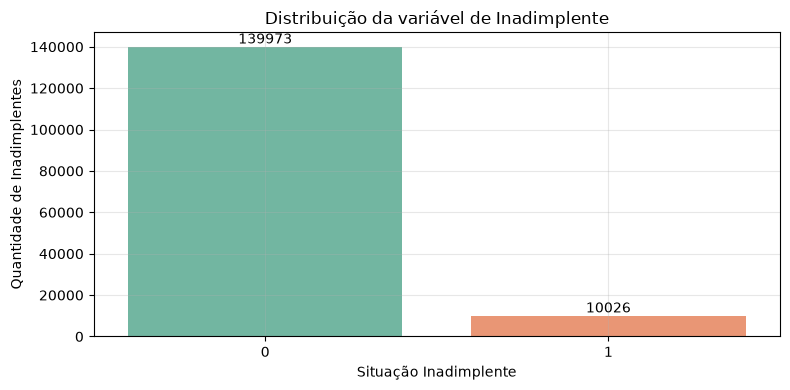

In [6]:
plt.figure(figsize=(8,4))

ax = sns.countplot(data=dados, x="inadimplente_2_anos", hue="inadimplente_2_anos", palette="Set2", legend=False)
plt.title("Distribuição da variável de Inadimplente")
plt.xlabel("Situação Inadimplente")
plt.ylabel("Quantidade de Inadimplentes")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusão — Variável Alvo

A variável alvo apresenta um **forte desbalanceamento entre as classes**.

- **Não inadimplentes:** aproximadamente 93%
- **Inadimplentes:** aproximadamente 7%

Isso representa uma proporção próxima de **14 clientes não inadimplentes para cada cliente inadimplente**.

Esse desbalanceamento deverá ser considerado durante a etapa de modelagem,
principalmente na divisão dos dados e na escolha das métricas de avaliação,
evitando depender apenas da acurácia.

# 4. Análise das Variáveis Numéricas

## 4.1 - Distribuição Geral

In [8]:
var_numericas = dados.select_dtypes(include="number").columns.difference(["inadimplente_2_anos"]).tolist()
print(var_numericas)

['atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias', 'emprestimos_imobiliarios', 'idade', 'linhas_credito_abertas', 'numero_dependentes', 'razao_divida', 'renda_mensal', 'utilizacao_credito']


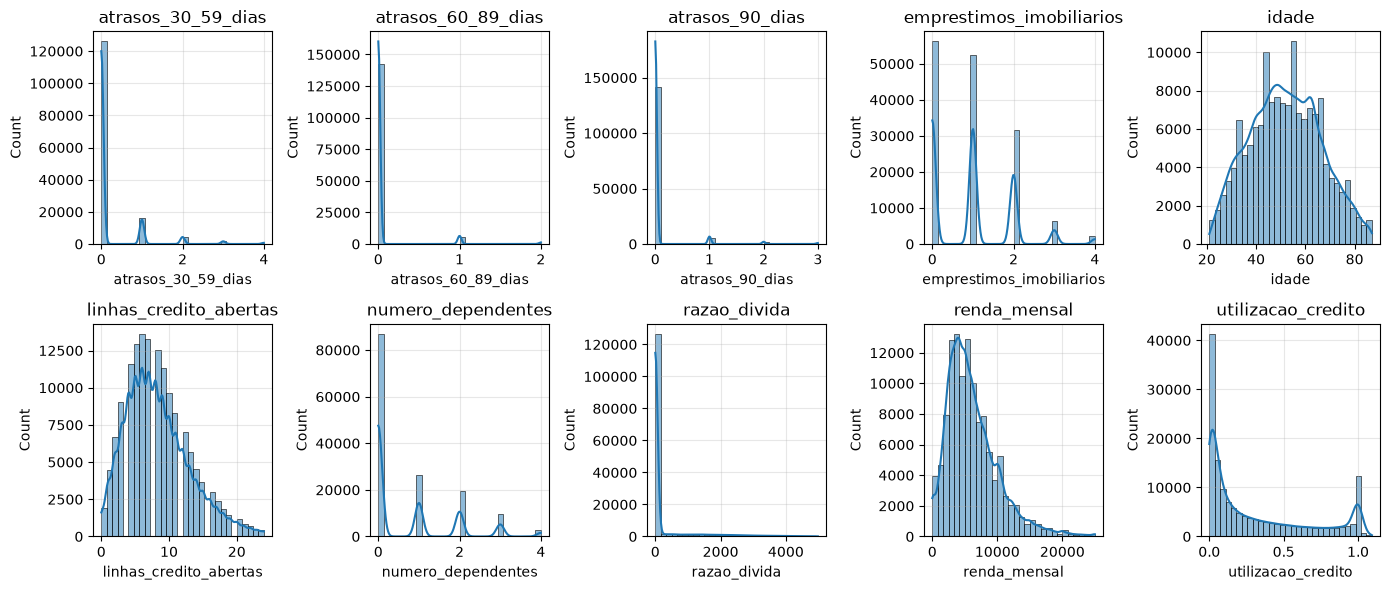

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(14,6))

axes = axes.flatten()

for i, coluna in enumerate(var_numericas):

    # Apenas para melhorar a visualização
    limite = dados[coluna].quantile(0.99)
    df_plot = dados[dados[coluna] <= limite]

    sns.histplot(data=df_plot, x=coluna, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(coluna)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observações iniciais

As distribuições mostram comportamentos distintos entre as variáveis numéricas.

As variáveis relacionadas a atrasos apresentam forte concentração em zero,
enquanto `renda_mensal`, `razao_divida` e `utilizacao_credito` apresentam
distribuições assimétricas e presença de valores extremos.

A variável `idade` apresenta distribuição mais regular, enquanto variáveis de
contagem, como número de dependentes, empréstimos imobiliários e linhas de
crédito, concentram-se em valores relativamente baixos.

A partir dessa análise inicial, as variáveis de utilização de crédito,
razão de dívida e histórico de atrasos serão observadas com maior atenção
na comparação com a variável alvo.

## 4.2 - Relação com a Inadimplência

### 4.2.1 - Utilização de Crédito

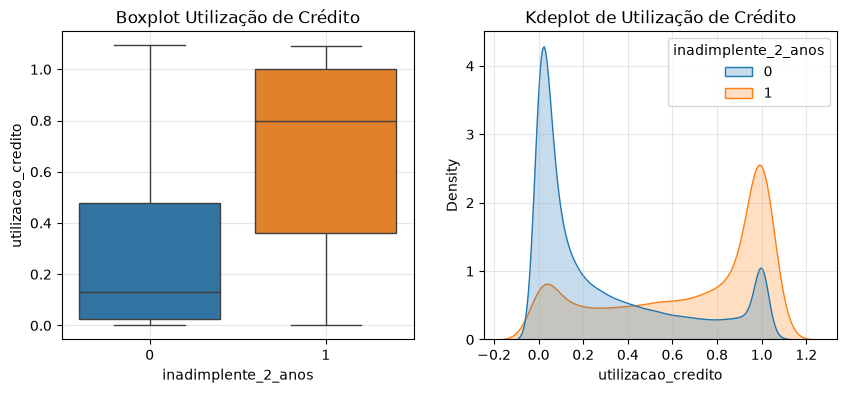

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

limite = dados["utilizacao_credito"].quantile(0.99)

df_plot = dados[dados["utilizacao_credito"] <= limite].copy()

sns.boxplot(data=df_plot, x="inadimplente_2_anos", y="utilizacao_credito", hue="inadimplente_2_anos", legend=False, ax=ax[0])
ax[0].set_title("Boxplot Utilização de Crédito")
ax[0].grid(alpha=0.3)

sns.kdeplot(data=df_plot, x="utilizacao_credito", hue="inadimplente_2_anos", fill=True, common_norm=False, ax=ax[1])
ax[1].set_title("Kdeplot de Utilização de Crédito")
ax[1].grid(alpha=0.3)

plt.show()

In [30]:
dados.groupby("inadimplente_2_anos")["utilizacao_credito"].agg(media="mean", mediana="median").round(3)

,media,mediana
inadimplente_2_anos,,
0,6.169,0.133
1,4.367,0.839


In [33]:
dados_eda = dados.copy()

dados_eda["faixa_utilizacao"] = pd.cut(dados_eda["utilizacao_credito"],
                                       bins=[0, 0.25, 0.50, 0.75, 1, float("inf")],
                                       labels=["0-25%", "25-50%", "50-75%", "75-100%", "Acima de 100%"])

analise_utilizacao = dados_eda.groupby("faixa_utilizacao")["inadimplente_2_anos"].agg(
    clientes="count", inadimplentes="sum", taxa_inadimplente="mean"
).round(3)

analise_utilizacao["taxa_inadimplente"] *= 100

analise_utilizacao

,clientes,inadimplentes,taxa_inadimplente
faixa_utilizacao,,,
0-25%,76779,1553,2.0
25-50%,21055,1114,5.3
50-75%,13764,1394,10.1
75-100%,24202,4408,18.2
Acima de 100%,3321,1237,37.2


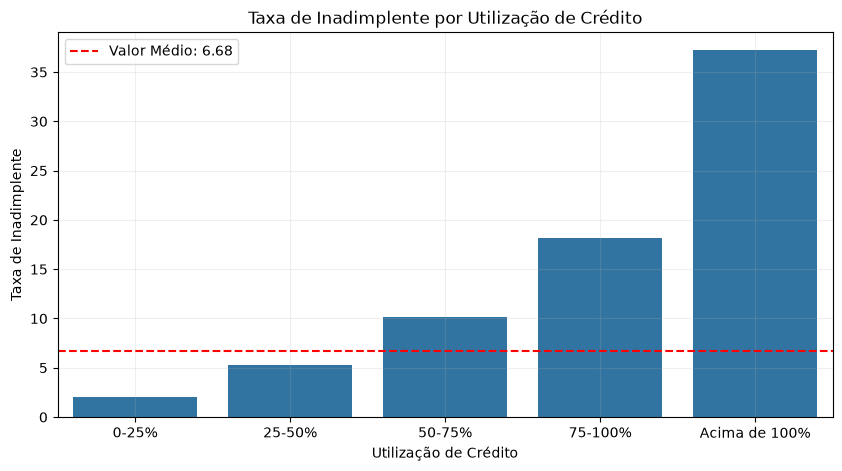

In [37]:
taxa_geral = dados["inadimplente_2_anos"].mean() * 100

plt.figure(figsize=(10,5))

sns.barplot(data=analise_utilizacao.reset_index(), x="faixa_utilizacao", y="taxa_inadimplente")
plt.axhline(taxa_geral, color="red", linestyle='--', label=f"Valor Médio: {taxa_geral:.2f}")
plt.title("Taxa de Inadimplente por Utilização de Crédito")
plt.xlabel("Utilização de Crédito")
plt.ylabel("Taxa de Inadimplente")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Conclusão — Utilização de Crédito

A utilização do crédito apresentou forte relação com a inadimplência.

Clientes não inadimplentes possuem mediana de utilização próxima de **13%**,
enquanto clientes inadimplentes apresentam mediana próxima de **84%**.

A análise por faixas reforça esse comportamento: a taxa de inadimplência cresce
de aproximadamente **2%** entre clientes que utilizam até 25% do crédito para
mais de **37%** entre aqueles com utilização superior a 100%.

Dessa forma, `utilizacao_credito` apresenta forte potencial preditivo para a
modelagem de risco de crédito.

### 4.2.1 - Idade

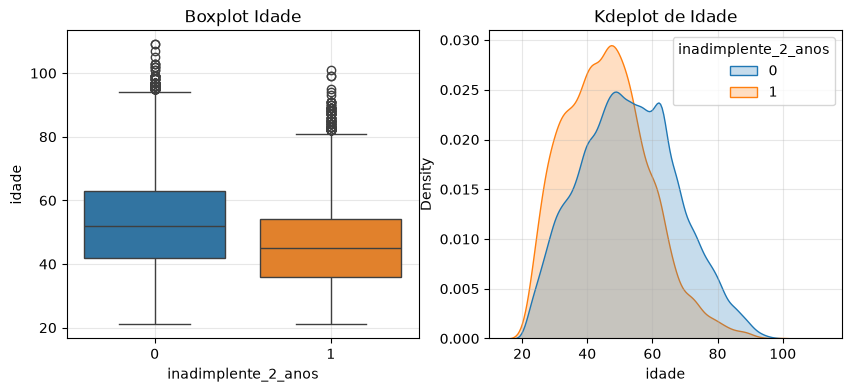

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=dados, x="inadimplente_2_anos", y="idade", hue="inadimplente_2_anos", ax=axes[0], legend=False)
axes[0].set_title("Boxplot Idade")
axes[0].grid(alpha=0.3)

sns.kdeplot(data=dados, x="idade", hue="inadimplente_2_anos", fill=True, common_norm=False, ax=axes[1])
axes[1].set_title("Kdeplot de Idade")
axes[1].grid(alpha=0.3)

plt.show()

In [39]:
dados.groupby("inadimplente_2_anos")["idade"].agg(media="mean", mediana="median").round(3)

,media,mediana
inadimplente_2_anos,,
0,52.752,52.0
1,45.927,45.0


In [42]:
dados_eda["faixa_etaria"] = pd.cut(
    dados_eda["idade"],
    bins=[18, 30, 40, 50, 60, 70, float("inf")],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "70+"],
    include_lowest=True
)

analise_idade = dados_eda.groupby("faixa_etaria")["inadimplente_2_anos"].agg(
    clientes="count", inadimplentes="sum", taxa_inadimplente="mean"
).round(3)

analise_idade["taxa_inadimplente"] *= 100
analise_idade

,clientes,inadimplentes,taxa_inadimplente
faixa_etaria,,,
18-30,10757,1244,11.6
31-40,24339,2390,9.8
41-50,35037,2893,8.3
51-60,34806,2149,6.2
61-70,27424,952,3.5
70+,17636,398,2.3


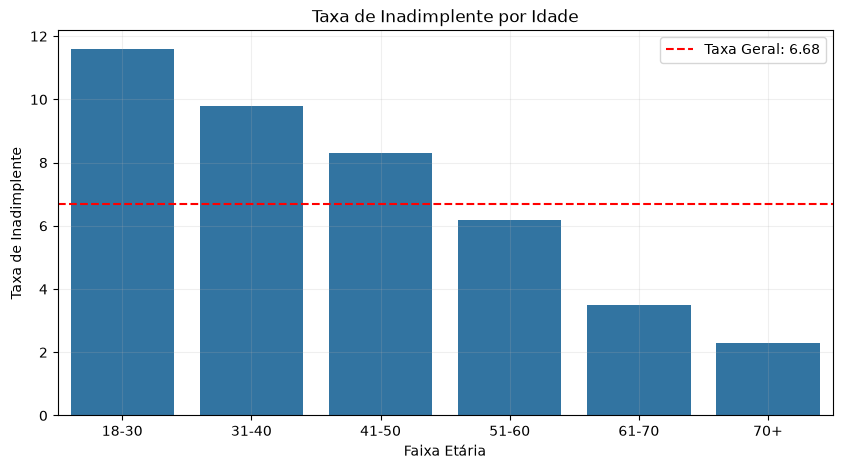

In [45]:
taxa_geral = dados["inadimplente_2_anos"].mean() * 100

plt.figure(figsize=(10,5))

sns.barplot(data=analise_idade.reset_index(), x="faixa_etaria", y="taxa_inadimplente")
plt.axhline(taxa_geral, color="red", linestyle='--', label=f"Taxa Geral: {taxa_geral:.2f}")
plt.title("Taxa de Inadimplente por Idade")
plt.xlabel("Faixa Etária")
plt.ylabel("Taxa de Inadimplente")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Conclusão — Idade

A idade apresentou uma relação clara com a inadimplência. Clientes
inadimplentes possuem idade mediana de **45 anos**, enquanto os não
inadimplentes apresentam mediana de **52 anos**.

A análise por faixas etárias reforça esse comportamento, com a taxa de
inadimplência diminuindo progressivamente de **11,6%** entre clientes de
18–30 anos para **2,3%** entre clientes com mais de 70 anos.

Dessa forma, a variável `idade` apresenta uma associação relevante com o
risco de inadimplência nesta base.

### 4.2.1 - Históricos de Atrasos

In [47]:
col_atrasos = [
    "atrasos_30_59_dias",
    "atrasos_60_89_dias",
    "atrasos_90_dias"
]

dados[col_atrasos].describe().T

,count,mean,std,min,25%,50%,75%,max
atrasos_30_59_dias,149999.0,0.421029,4.192795,0.0,0.0,0.0,0.0,98.0
atrasos_60_89_dias,149999.0,0.240388,4.155193,0.0,0.0,0.0,0.0,98.0
atrasos_90_dias,149999.0,0.265975,4.169318,0.0,0.0,0.0,0.0,98.0


In [ ]:
df_atrasos = dados[(dados[col_atrasos] < 90).all(axis=1)].copy()

In [ ]:
resultados = []

for col in col_atrasos:

    temp = df_atrasos[[col, "inadimplente_2_anos"]].copy()

    temp["faixa_atrasos"] = pd.cut(
        temp[col],
        bins=[-1, 0, 1, 2, float("inf")],
        labels=["0", "1", "2", "3+"]
    )

    resumo = (
        temp.groupby("faixa_atrasos", observed=False)["inadimplente_2_anos"]
        .mean()
        .mul(100)
        .reset_index(name="taxa_inadimplencia")
    )

    resumo["tipo_atraso"] = col
    resultados.append(resumo)

analise_atrasos = pd.concat(resultados)

analise_atrasos.round(2)

,faixa_atrasos,taxa_inadimplencia,tipo_atraso
0,0,4.00,atrasos_30_59_dias
1,1,15.03,atrasos_30_59_dias
2,2,26.51,atrasos_30_59_dias
3,3+,39.26,atrasos_30_59_dias
0,0,5.10,atrasos_60_89_dias
1,1,31.01,atrasos_60_89_dias
2,2,50.18,atrasos_60_89_dias
3,3+,58.64,atrasos_60_89_dias
0,0,4.63,atrasos_90_dias
1,1,33.66,atrasos_90_dias


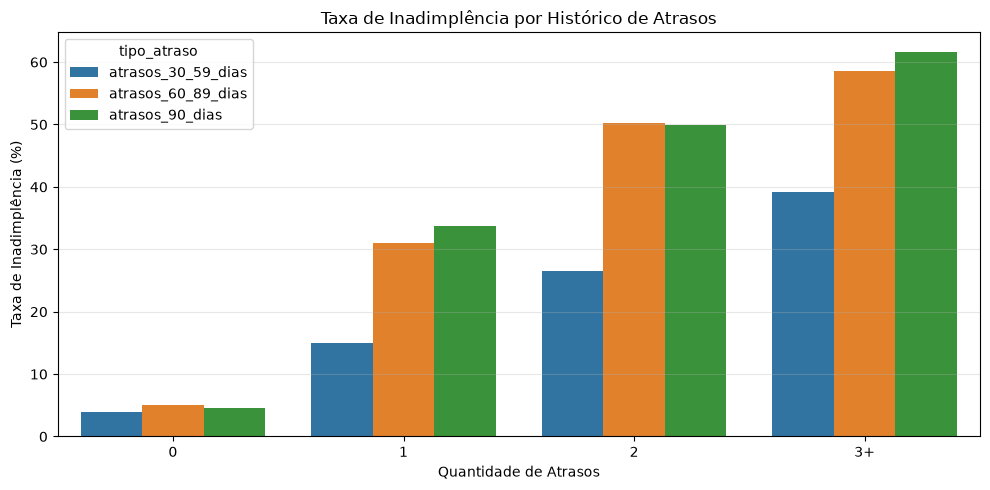

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=analise_atrasos,
    x="faixa_atrasos",
    y="taxa_inadimplencia",
    hue="tipo_atraso"
)

plt.title("Taxa de Inadimplência por Histórico de Atrasos")
plt.xlabel("Quantidade de Atrasos")
plt.ylabel("Taxa de Inadimplência (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusão — Histórico de Atrasos

O histórico de atrasos apresentou uma relação clara com a inadimplência.

Em todas as faixas analisadas, a taxa de inadimplência aumentou conforme cresceu a quantidade de atrasos. Esse comportamento foi especialmente forte nos atrasos de **60–89 dias** e de **90 dias ou mais**.

Entre clientes com 3 ou mais atrasos, a taxa de inadimplência chegou a aproximadamente **58,6%** para atrasos de 60–89 dias e **61,7%** para atrasos de 90 dias ou mais.

Esses resultados indicam que as variáveis de atraso possuem forte potencial preditivo e devem ter importância relevante na modelagem de risco de crédito.

# 5. Correlação das Variáveis

In [53]:
var_numericas = dados.select_dtypes(include="number").columns.to_list()

corr = dados[var_numericas].corr(method="spearman")

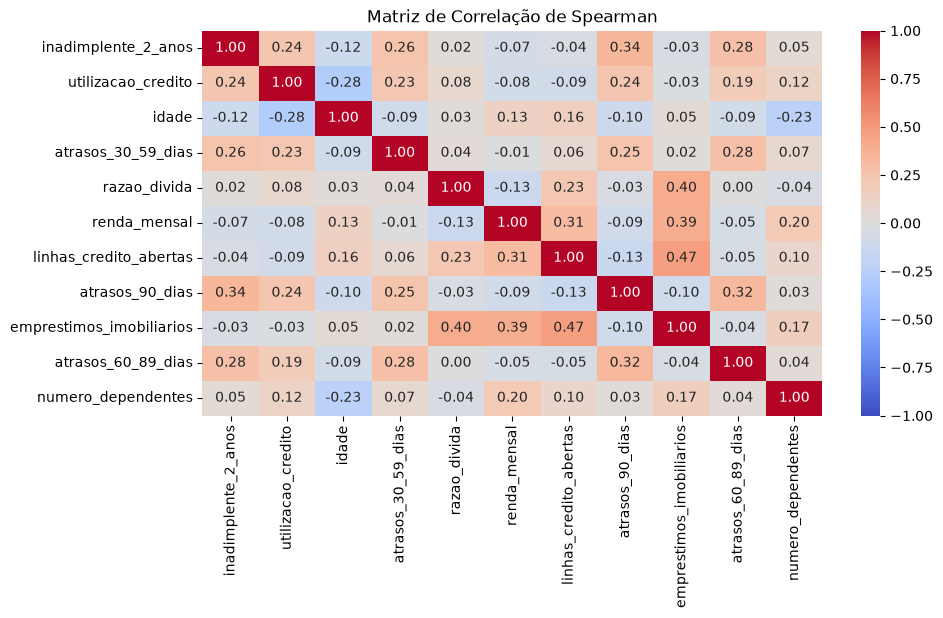

In [76]:
plt.figure(figsize=(10,5))

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de Correlação de Spearman")
plt.show()

In [55]:
correlacao = corr["inadimplente_2_anos"].drop("inadimplente_2_anos").sort_values(key=abs, ascending=False).round(3)
correlacao

atrasos_90_dias             0.342
atrasos_60_89_dias          0.277
atrasos_30_59_dias          0.257
utilizacao_credito          0.240
idade                      -0.117
renda_mensal               -0.067
numero_dependentes          0.046
linhas_credito_abertas     -0.039
emprestimos_imobiliarios   -0.034
razao_divida                0.021
Name: inadimplente_2_anos, dtype: float64

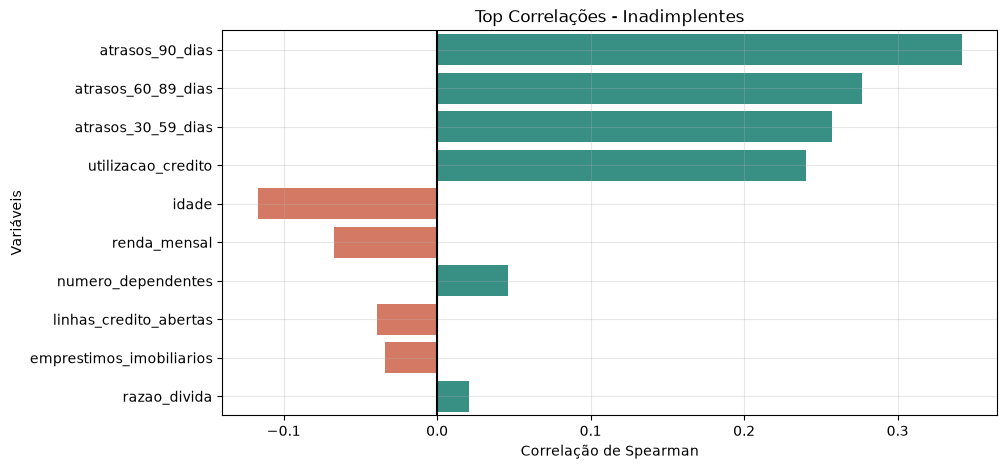

In [80]:
plt.figure(figsize=(10,5))

cores = ["#2a9d8f" if valor >= 0 else "#e76f51"
         for valor in correlacao.values]

sns.barplot(x=correlacao.values, y=correlacao.index, hue=correlacao.index, palette=cores, legend=False)
plt.axvline(0, color="black", linewidth=1.5)
plt.title("Top Correlações - Inadimplentes")
plt.xlabel("Correlação de Spearman")
plt.ylabel("Variáveis")
plt.grid(alpha=0.3)
plt.show()

### Conclusão — Correlação

A análise de correlação reforçou os padrões identificados durante a EDA.

As variáveis com maior associação positiva com a inadimplência foram
`atrasos_90_dias`, `atrasos_60_89_dias`, `atrasos_30_59_dias` e
`utilizacao_credito`, destacando a importância do comportamento de pagamento
e da utilização do crédito na identificação de clientes de maior risco.

A variável `idade` apresentou correlação negativa com o target, indicando
menor incidência de inadimplência entre clientes mais velhos nesta base.

As demais variáveis apresentaram correlações mais fracas com a variável alvo.
Entretanto, isso não implica ausência de poder preditivo, pois podem existir
relações não lineares e interações entre as características.

Também não foram observadas correlações extremamente elevadas entre as
variáveis preditoras, não indicando multicolinearidade severa nesta análise.

# 6. Feature Engineering — Histórico de Atrasos

Com base nos padrões identificados durante a análise exploratória,
foram criadas novas variáveis para sintetizar o comportamento de pagamento
dos clientes e representar a gravidade do histórico de atrasos.

In [58]:
dados_fe = dados.copy()

In [67]:
# Total de atrasos
dados_fe["total_atrasos"] = (
    dados_fe["atrasos_30_59_dias"] + dados_fe["atrasos_60_89_dias"] + dados_fe["atrasos_90_dias"]
)

# Possui Atraso grave
dados_fe["atraso_grave"] = (dados_fe["atrasos_90_dias"] > 0).astype(int)

In [72]:
df_plot.groupby("inadimplente_2_anos")[
    ["total_atrasos", "atraso_grave"]
].agg({
    "total_atrasos": ["mean", "median"],
    "atraso_grave": "mean"
}).round(2)

total_atrasos        atraso_grave
                             mean median         mean
inadimplente_2_anos                                  
0                            0.29    0.0         0.03
1                            2.03    1.0         0.34

In [73]:
col_atrasos = [
    "atrasos_30_59_dias",
    "atrasos_60_89_dias",
    "atrasos_90_dias"
]

# Base apenas para visualização, sem os valores anormais de atraso
df_plot = dados_fe[
    (dados_fe[col_atrasos] < 90).all(axis=1)
].copy()


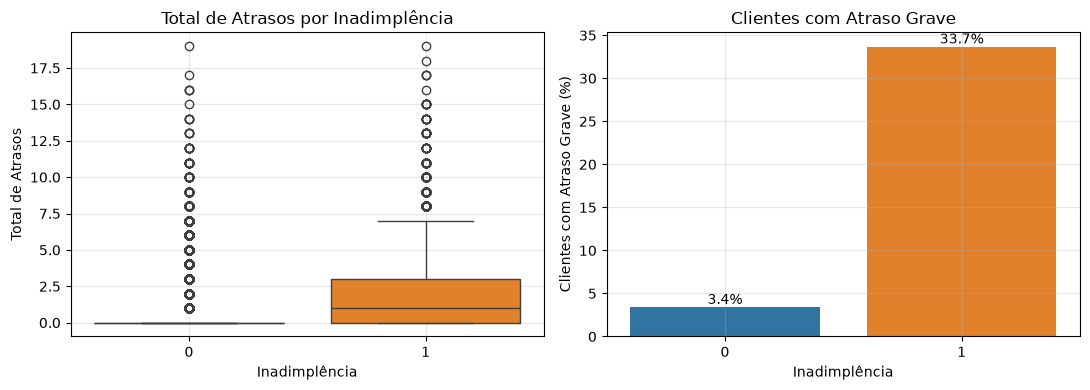

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Total de atrasos
sns.boxplot(data=df_plot, x="inadimplente_2_anos", y="total_atrasos", hue="inadimplente_2_anos", legend=False, ax=ax[0])
ax[0].set_title("Total de Atrasos por Inadimplência")
ax[0].set_xlabel("Inadimplência")
ax[0].set_ylabel("Total de Atrasos")
ax[0].grid(alpha=0.3)

# Percentual com atraso grave
grave = (df_plot.groupby("inadimplente_2_anos")["atraso_grave"].mean().mul(100).reset_index())

sns.barplot(data=grave, x="inadimplente_2_anos", y="atraso_grave", hue="inadimplente_2_anos", legend=False, ax=ax[1])
ax[1].set_title("Clientes com Atraso Grave")
ax[1].set_xlabel("Inadimplência")
ax[1].set_ylabel("Clientes com Atraso Grave (%)")
ax[1].grid(alpha=0.3)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

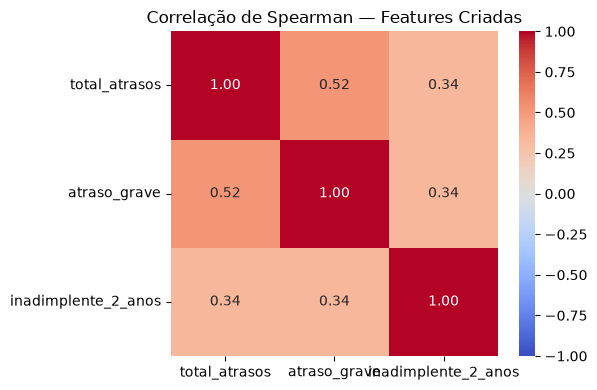

In [75]:
corr_fe = dados_fe[
    ["total_atrasos", "atraso_grave", "inadimplente_2_anos"]
].corr(method="spearman").round(2)

plt.figure(figsize=(6, 4))

sns.heatmap(corr_fe, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")

plt.title("Correlação de Spearman — Features Criadas")
plt.tight_layout()
plt.show()

### Conclusão — Feature Engineering

Com base nos padrões identificados na análise exploratória, foram criadas as variáveis `total_atrasos` e `atraso_grave` para sintetizar o histórico de pagamento dos clientes.

A variável `total_atrasos` representa a recorrência de atrasos, enquanto `atraso_grave` identifica clientes que já apresentaram atraso de 90 dias ou mais.

As duas features apresentaram associação relevante com a inadimplência e correlação moderada entre si, indicando que capturam informações relacionadas, mas não totalmente redundantes.

Dessa forma, ambas serão mantidas para a etapa de modelagem, onde será avaliado se contribuem para melhorar o desempenho preditivo dos modelos.